# SMARTCART - E-commerce customer segregation system

In [101]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [164]:
df=pd.read_csv("smartcart_customers.csv")

In [165]:
df.shape

(2240, 22)

In [166]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64
dtype: object

In [167]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [168]:
# to check if the dataset contains any null value or not 
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# DATA PRE-PROCESSING

# 1. Handel Missing Value

In [169]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# 2.Feature Enginerring

In [170]:
# derive age from year_Birth column
df["Age"] = 2026-df["Year_Birth"]

In [171]:
# to find tenure period from date of joining column
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
#here dayfirst means we have format dd-mm-yyyy but pandas except the format mm-dd-yyyy


In [172]:
# derive total spending from coulmnc Mntwines,MntGoldProds,MntMeatProducts,MntFishProducts,MntFruits,Mntsweetproduct
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [173]:
# derive total children from teenhome and kidhome column
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [174]:
# education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [175]:
# derive living with column from martital status column
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [178]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [179]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [180]:
# drop columns that is no more neede 
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [181]:
df_cleaned=df.drop(columns=column_drop)

In [182]:
df_cleaned.shape

(2240, 15)

# outliers

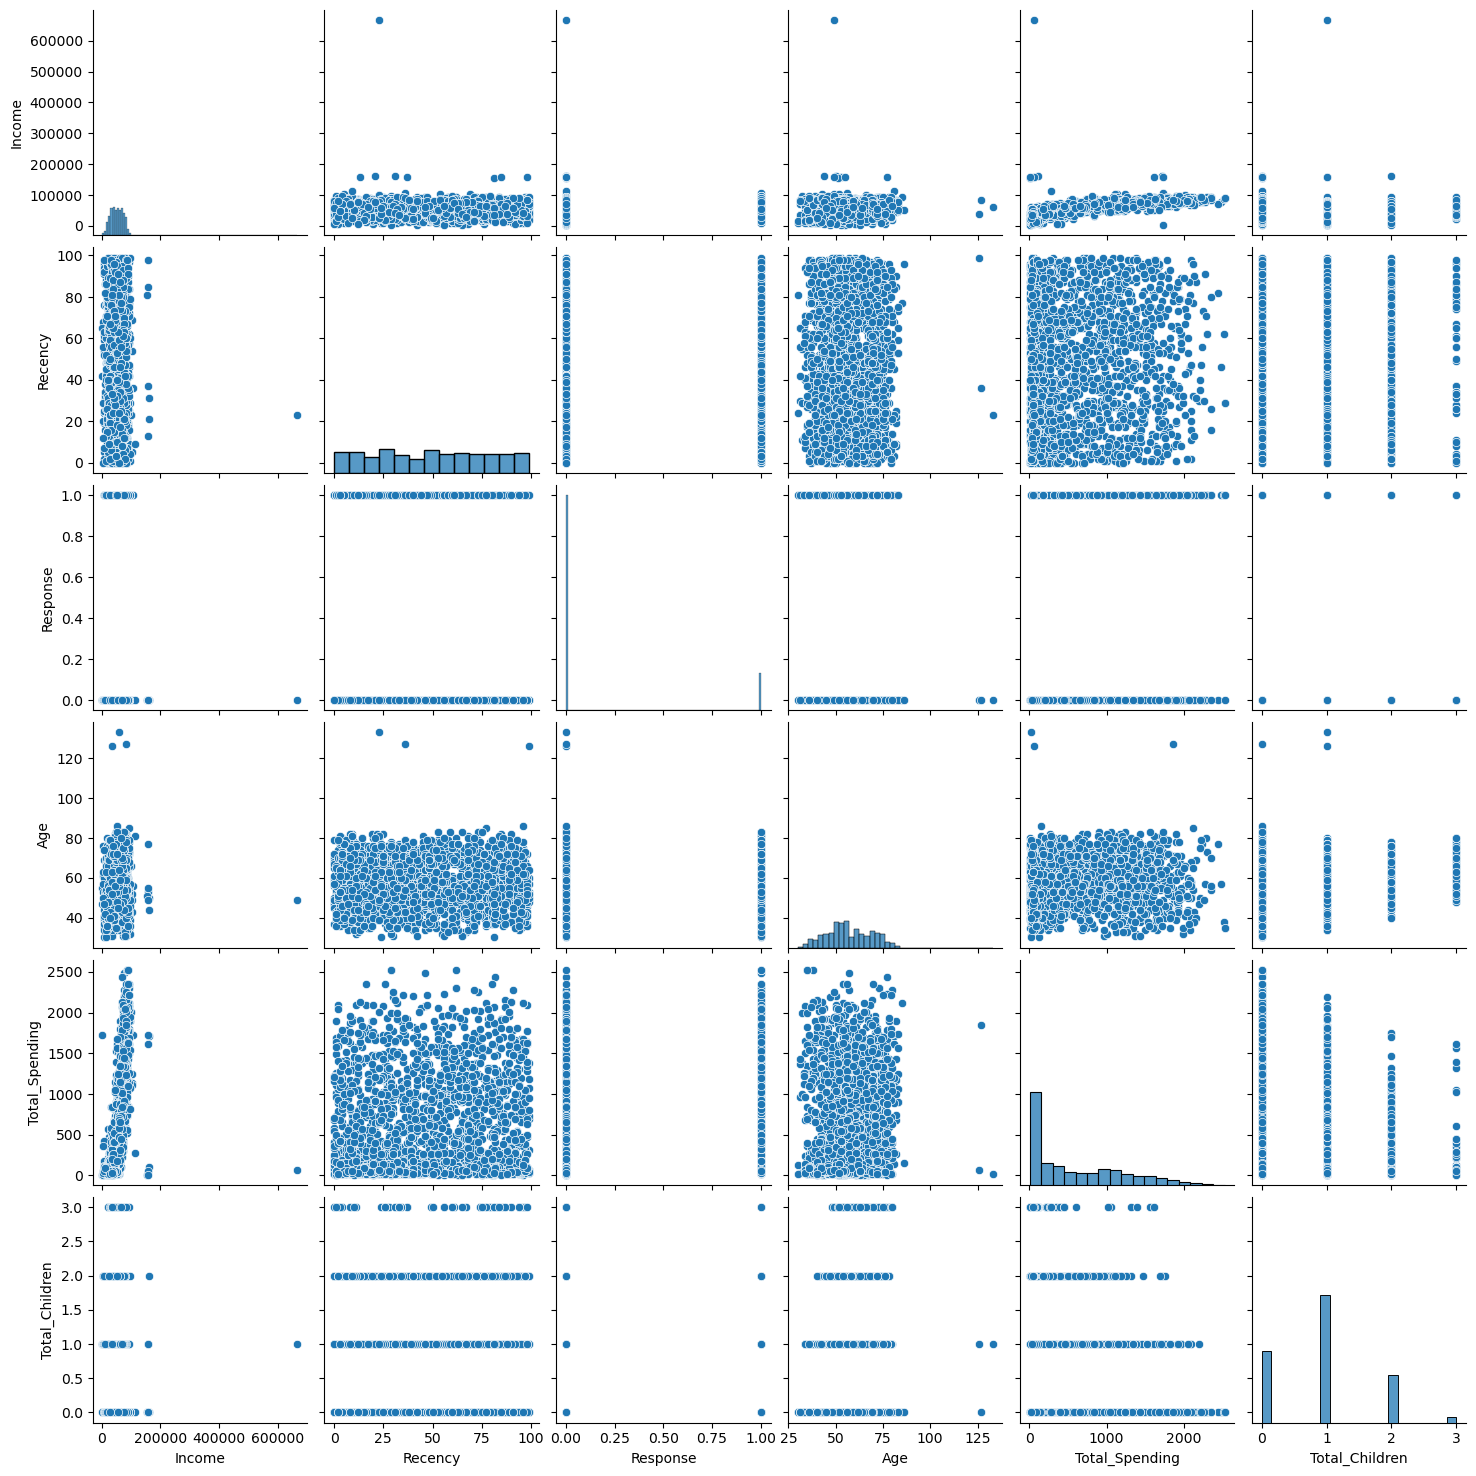

In [183]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [184]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# heatmaps to check the correlation 

<Axes: >

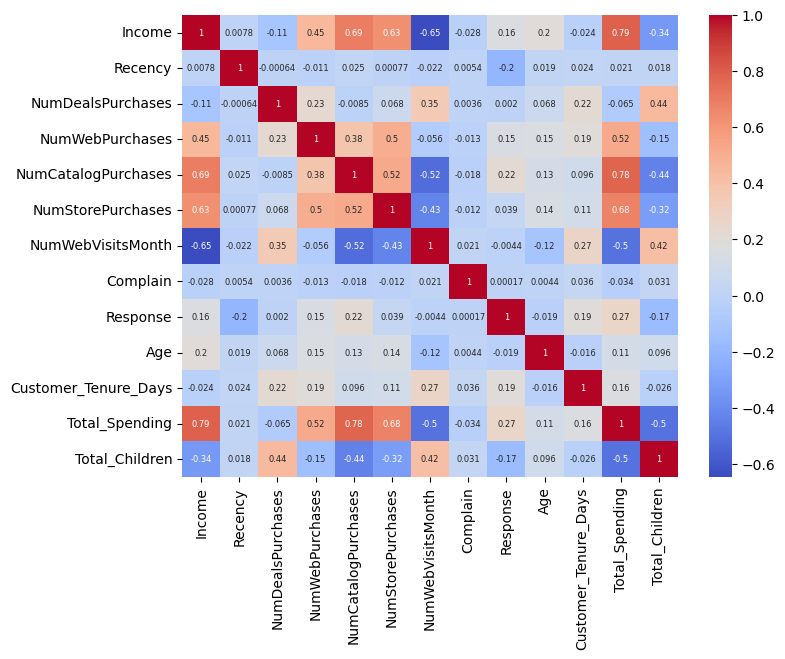

In [185]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)
# here we can conclude that if income increases then total_Spending also increases

# Encoding

In [186]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [187]:
df_encoded.shape

(2236, 18)

In [188]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [189]:
df_encoded.dtypes

Income                     float64
Recency                      int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
Complain                     int64
Response                     int64
Age                          int64
Customer_Tenure_Days         int64
Total_Spending               int64
Total_Children               int64
Education_Graduate         float64
Education_Postgraduate     float64
Education_Undergraduate    float64
Living_With_Alone          float64
Living_With_Partner        float64
dtype: object

In [190]:
# scaling data
from sklearn.preprocessing import StandardScaler
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [191]:
# visualization
X_scaled.shape

(2236, 18)

In [192]:
#2d 
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(X_scaled)

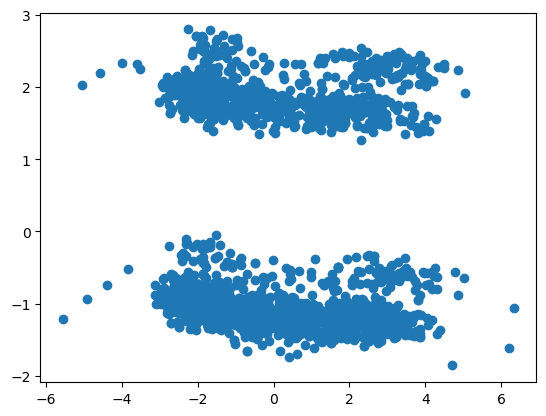

In [193]:
#plot 
plt.scatter(x=x_pca[:,0],y=x_pca[:,1])

In [194]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

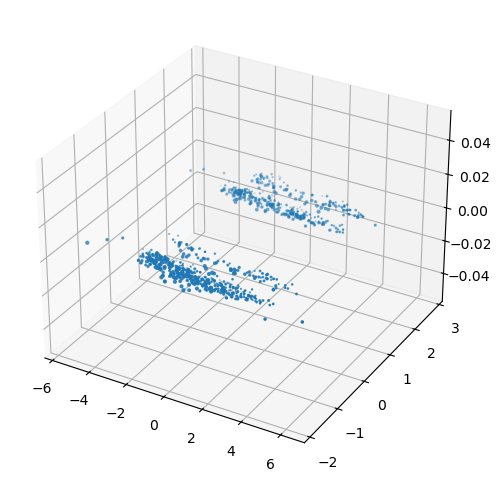

In [196]:
#plot 
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

In [207]:
# analysis k value
# elbow method
from sklearn.cluster import KMeans 
from kneed import KneeLocator
wcss=[]
for i in range(1,11):
          kmeans=KMeans(n_clusters=i,random_state=42)
          kmeans.fit_predict(x_pca)
          wcss.append(kmeans.inertia_)


In [208]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [209]:
print("best k=",optimal_k)

best k= 4


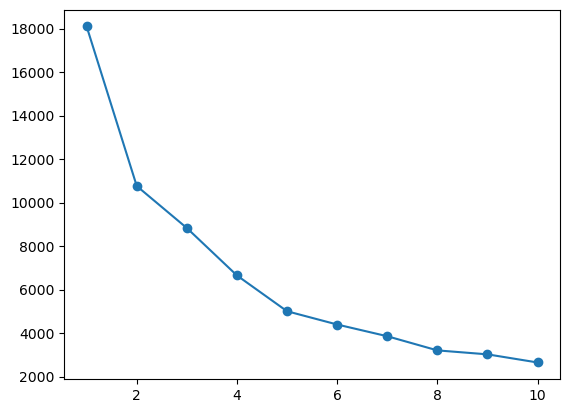

In [210]:
#plot
plt.plot(range(1,11),wcss,marker='o')

Text(0, 0.5, 'Silhouette score')

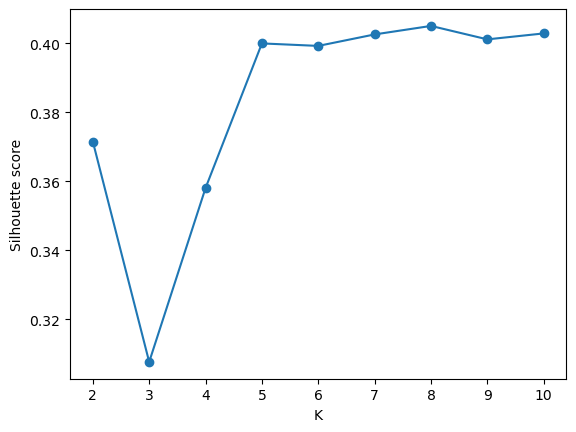

In [211]:
# silhouette score
from sklearn.metrics import silhouette_score
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'ss')

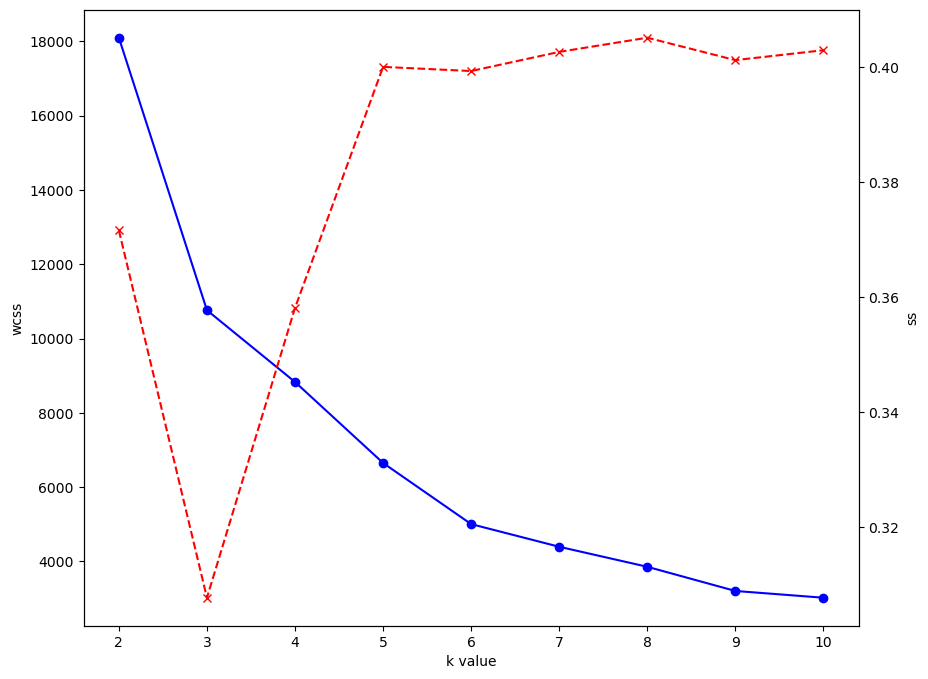

In [218]:
#combine plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax2=ax1.twinx()
ax1.set_ylabel("wcss")
ax1.set_xlabel("k value")
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("ss")

In [154]:
# clustering

# K Means

In [219]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels=kmeans.fit_predict(x_pca)


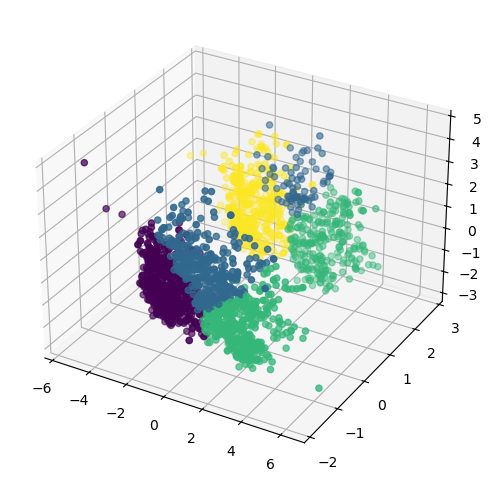

In [220]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

# agglomerative

In [221]:
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(x_pca)


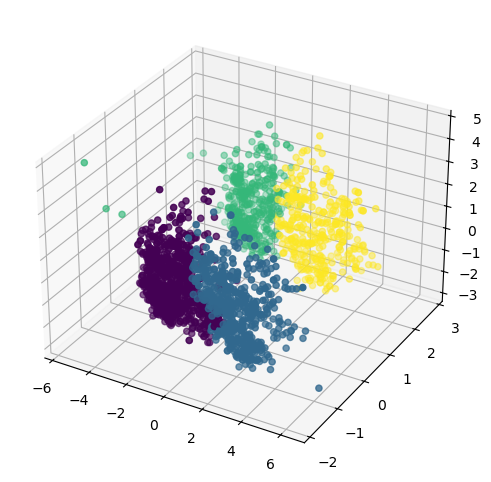

In [222]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

# characterization of clusters 

In [228]:
X["cluster"] = labels_agg

In [229]:
x.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,labels
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='cluster', ylabel='count'>

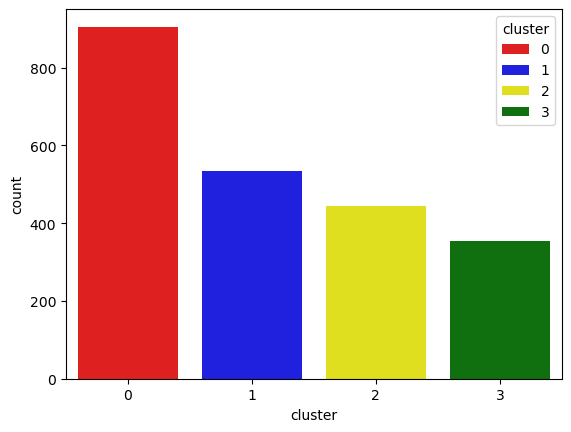

In [230]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

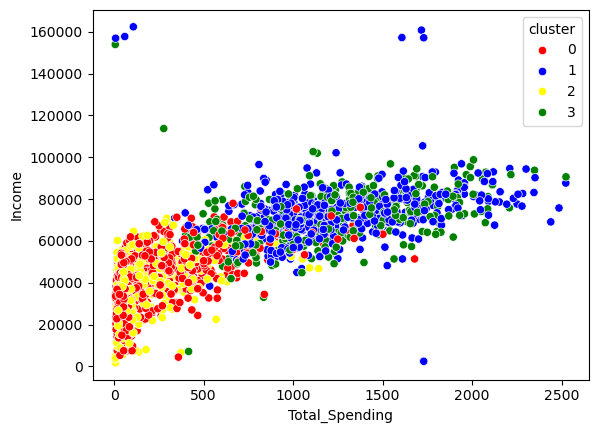

In [235]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [236]:
# cluster :Red
Income : low/moderate
Spending :low and moderate 
#cluster :Blue 
income: high
spending:high
#cluster :yellow 
income :low
spending :loe
#cluster green
income :moderate to high
spending :high

In [238]:
# cluster summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         